# O6 Multimodal — 30 instances
Five fixed depths, staged `3 → 6 → 9 → 20`, and rotating `{3, 9, 20}` every 50 trials.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
if HERE.name != "05_30_instances":
    HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o6_multi_modal/depth_policies/05_30_instances")
OUTPUT_DIRECTORY = HERE / "smac_output"
DIMENSION = 10
N_INSTANCES = 30
DEPTHS = (3, 6, 9, 15, 20)
FIXED = tuple(f"fixed_depth_{d}" for d in DEPTHS)
STAGED = "staged_depth_3_6_9_20"
ROTATING = "random_depth_3_9_20_every_50"
POLICIES = FIXED + (STAGED, ROTATING)
SEEDS = tuple(range(5))
N_TRIALS = 1500
CHECKPOINTS = tuple(range(100, N_TRIALS + 1, 100))
LABELS = {f"fixed_depth_{d}": f"depth = {d}" for d in DEPTHS}
LABELS.update({STAGED:"staged 3 → 6 → 9 → 20", ROTATING:"rotating {3, 9, 20} / 50"})
COLORS = dict(zip(POLICIES, ("C0","C1","C2","C3","C4","black","C6")))

In [2]:
def load(policy):
    runs={}
    for path in (OUTPUT_DIRECTORY/policy).rglob("trajectory.json"):
        result=json.loads(path.read_text())
        if result["smac_seed"] in SEEDS and result["n_trials"] == N_TRIALS:
            runs[result["smac_seed"]]=result
    missing=sorted(set(SEEDS)-set(runs))
    if missing: raise FileNotFoundError(f"Missing {policy}: seeds={missing}")
    return runs

results={p:load(p) for p in POLICIES}
for policy,runs in results.items():
    for result in runs.values():
        assert result["problem"]=="O6-Multimodal"
        assert result["dimension"]==DIMENSION
        assert result["n_instances"]==N_INSTANCES
        assert len(result["instance_map"])==N_INSTANCES
        assert result["problem_seed"]==52
        assert result["initial_design"]=="random" and result["n_initial_configs"]==10
        assert result["initial_design_seed"]==result["smac_seed"]
        if policy in FIXED: assert result["max_depth"]==int(policy.rsplit("_",1)[1])
        elif policy==STAGED:
            assert result["stage_boundaries"]==[100,200,500]
            assert result["depth_schedule"]==[3,6,9,20]
        else:
            assert result["block_size"]==50
            assert result["depth_choices"]==[3,9,20]
print(f"Loaded {sum(map(len,results.values()))}/35 trajectories.")

Loaded 35/35 trajectories.


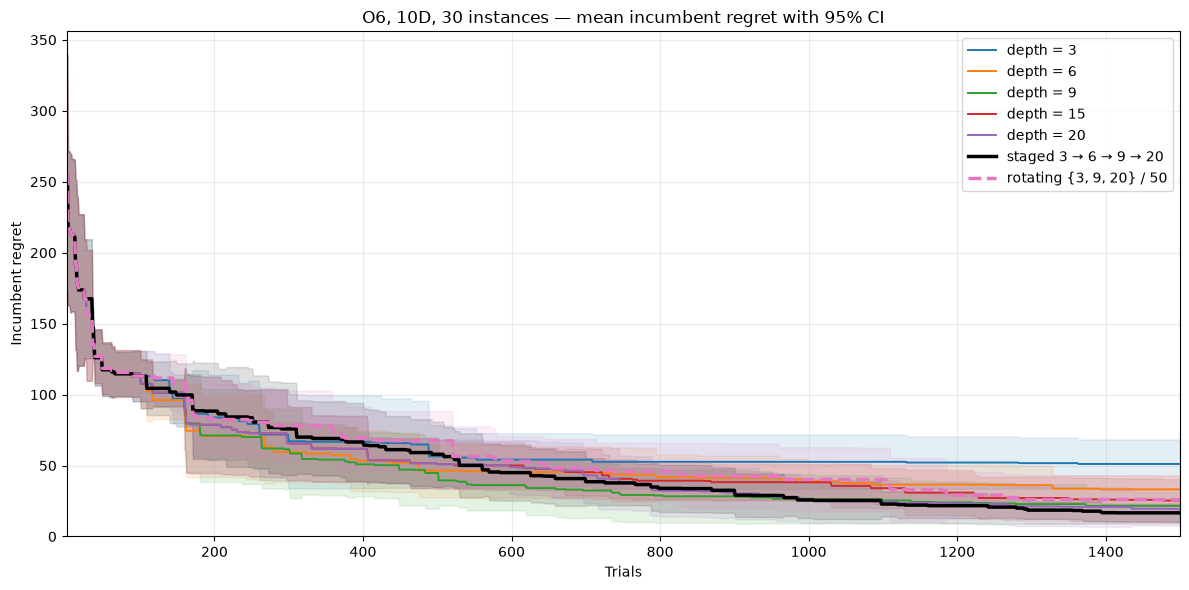

In [3]:
rows=[{"policy":p,"seed":s,"iteration":i,"best_regret":r} for p,runs in results.items() for s,result in runs.items() for i,r in zip(result["iteration"],result["best_regret"])]
trajectories=pd.DataFrame(rows)
summary=trajectories.groupby(["policy","iteration"])["best_regret"].agg(["mean","std","count"]).reset_index()
summary["ci95"]=1.96*summary["std"]/np.sqrt(summary["count"])
fig,ax=plt.subplots(figsize=(12,6))
for p in POLICIES:
    d=summary[summary.policy==p]; style="--" if p==ROTATING else "-"; width=2.5 if p in (STAGED,ROTATING) else 1.4
    ax.plot(d.iteration,d["mean"],label=LABELS[p],color=COLORS[p],linestyle=style,linewidth=width)
    ax.fill_between(d.iteration,np.maximum(0,d["mean"]-d.ci95),d["mean"]+d.ci95,color=COLORS[p],alpha=.12)
ax.set(title="O6, 10D, 30 instances — mean incumbent regret with 95% CI",xlabel="Trials",ylabel="Incumbent regret",xlim=(1,N_TRIALS),ylim=(0,None)); ax.grid(alpha=.25); ax.legend(); plt.tight_layout(); plt.show()

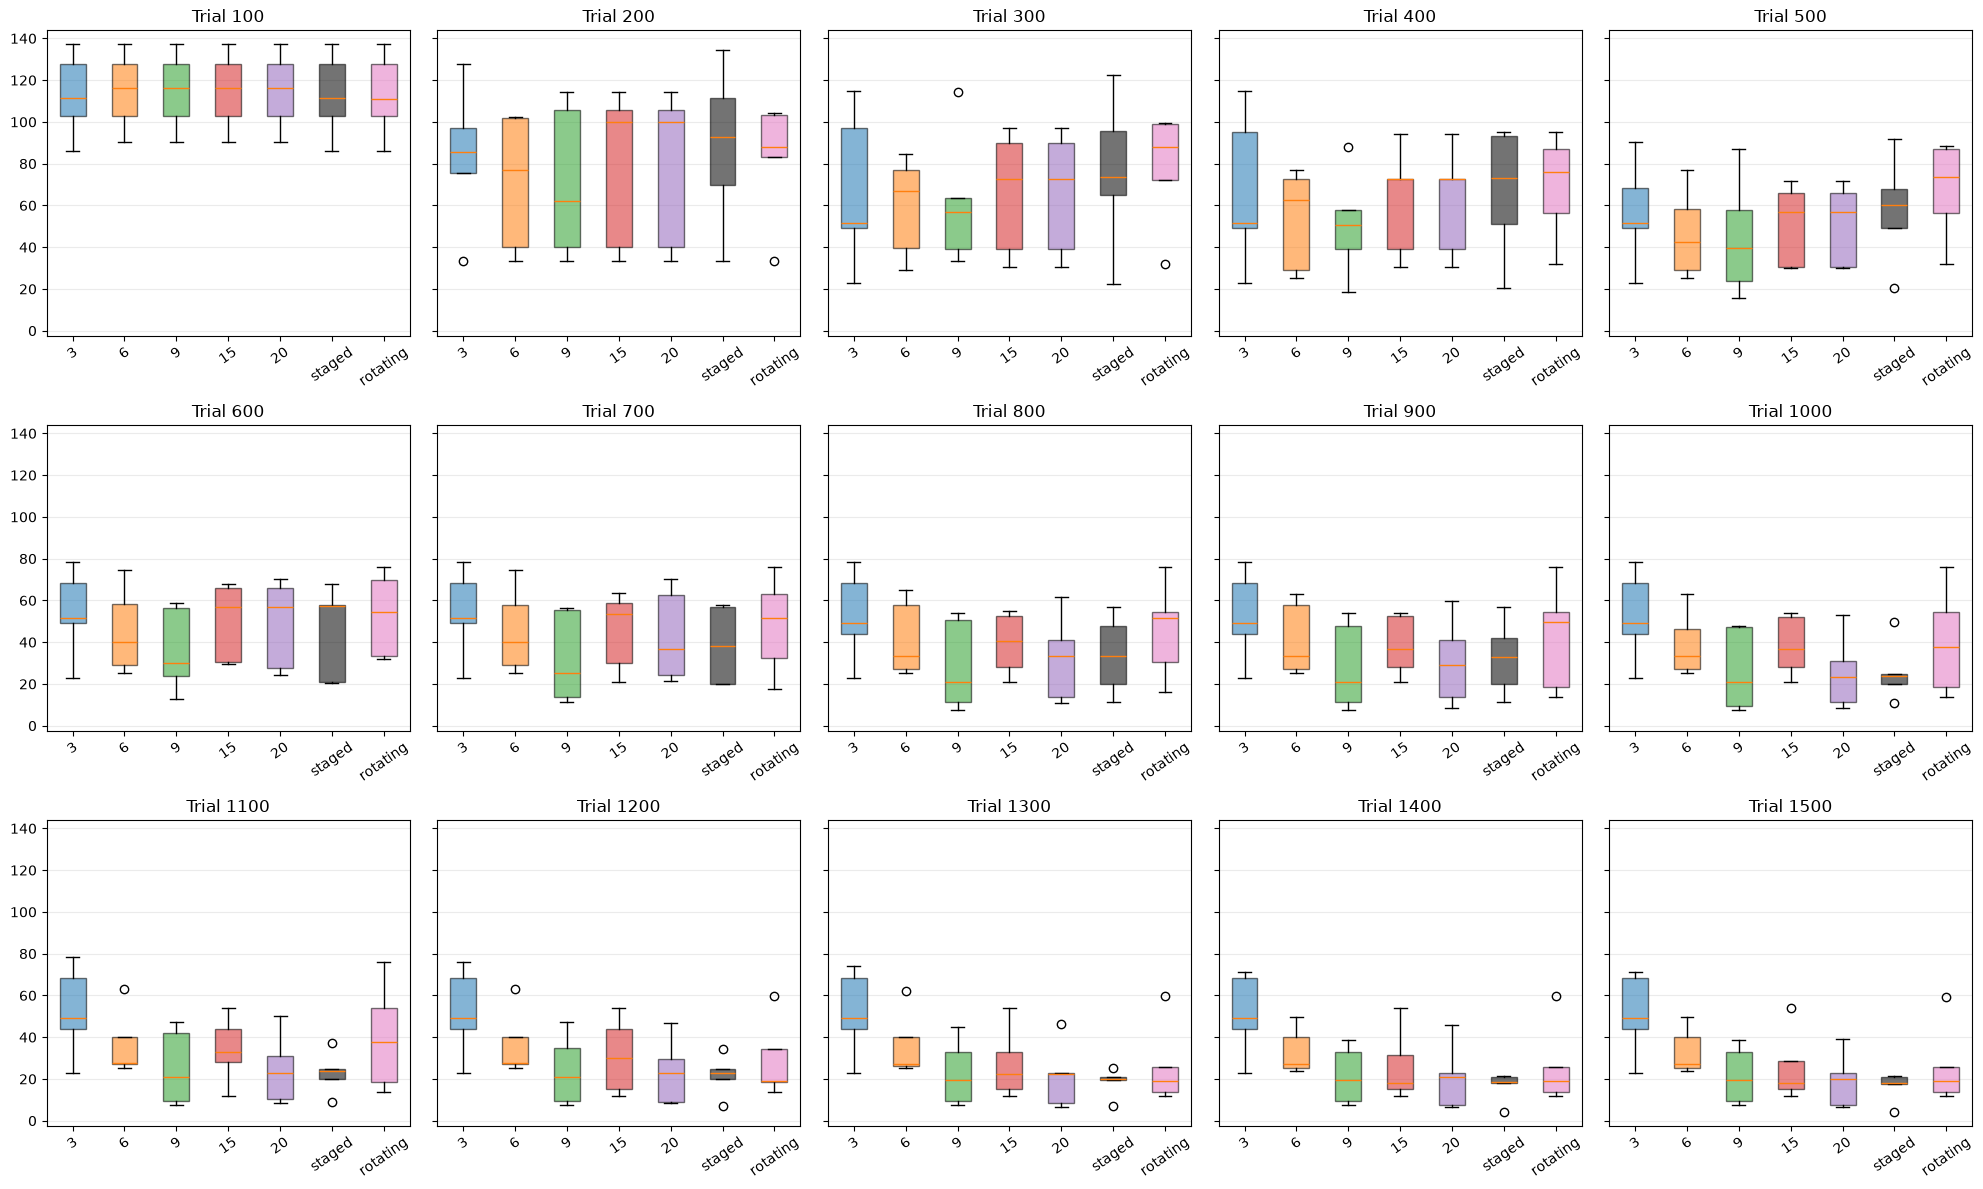

In [4]:
fig,axes=plt.subplots(3,5,figsize=(20,12),sharey=True)
for ax,checkpoint in zip(axes.flat,CHECKPOINTS):
    values=[[results[p][s]["best_regret"][checkpoint-1] for s in SEEDS] for p in POLICIES]
    boxes=ax.boxplot(values,patch_artist=True,tick_labels=[str(d) for d in DEPTHS]+["staged","rotating"])
    for box,p in zip(boxes["boxes"],POLICIES): box.set(facecolor=COLORS[p],alpha=.55)
    ax.set_title(f"Trial {checkpoint}"); ax.tick_params(axis="x",rotation=35); ax.grid(axis="y",alpha=.25)
plt.tight_layout(); plt.show()

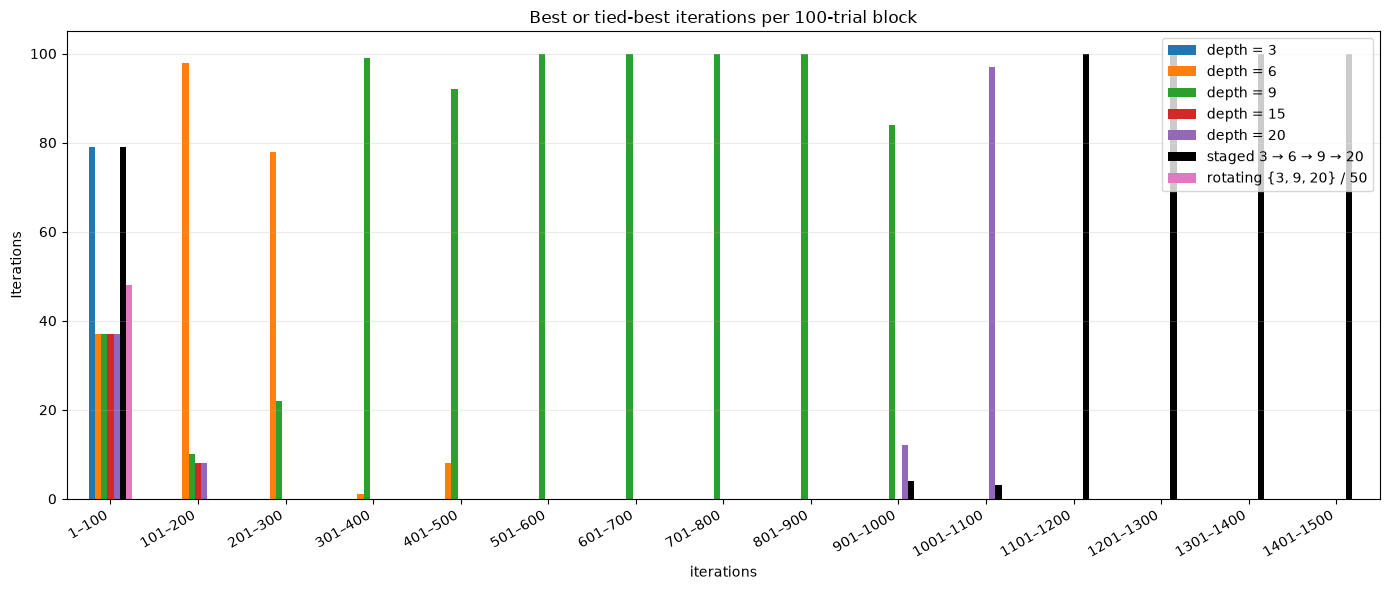

,iterations,superior policy,depth = 3,depth = 6,depth = 9,depth = 15,depth = 20,staged 3 → 6 → 9 → 20,"rotating {3, 9, 20} / 50"
0,1–100,"depth = 3, staged 3 → 6 → 9 → 20",79,37,37,37,37,79,48
1,101–200,depth = 6,0,98,10,8,8,0,0
2,201–300,depth = 6,0,78,22,0,0,0,0
3,301–400,depth = 9,0,1,99,0,0,0,0
4,401–500,depth = 9,0,8,92,0,0,0,0
5,501–600,depth = 9,0,0,100,0,0,0,0
6,601–700,depth = 9,0,0,100,0,0,0,0
7,701–800,depth = 9,0,0,100,0,0,0,0
8,801–900,depth = 9,0,0,100,0,0,0,0
9,901–1000,depth = 9,0,0,84,0,12,4,0


In [5]:
mean_regret=trajectories.pivot_table(index="iteration",columns="policy",values="best_regret",aggfunc="mean").reindex(columns=POLICIES)
best=mean_regret.min(axis=1)
wins=pd.DataFrame({p:np.isclose(mean_regret[p],best,rtol=1e-12,atol=1e-9) for p in POLICIES},index=mean_regret.index)
block_rows=[]
for end in CHECKPOINTS:
    counts=wins.loc[end-99:end].sum(); maximum=int(counts.max())
    row={"iterations":f"{end-99}–{end}","superior policy":", ".join(LABELS[p] for p in POLICIES if counts[p]==maximum)}
    row.update({LABELS[p]:int(counts[p]) for p in POLICIES}); block_rows.append(row)
block_superiority=pd.DataFrame(block_rows)
ax=block_superiority.set_index("iterations")[[LABELS[p] for p in POLICIES]].plot(kind="bar",figsize=(14,6),color=[COLORS[p] for p in POLICIES])
ax.set(title="Best or tied-best iterations per 100-trial block",ylabel="Iterations",ylim=(0,105)); ax.grid(axis="y",alpha=.25); plt.xticks(rotation=30,ha="right"); plt.tight_layout(); plt.show()
block_superiority

In [6]:
table=trajectories[trajectories.iteration.isin(CHECKPOINTS)].groupby(["iteration","policy"])["best_regret"].agg(["mean","std","min","median","max"])
with pd.option_context("display.max_rows",None,"display.max_columns",None,"display.width",None): display(table)

mean        std        min  \
iteration policy                                                           
100       fixed_depth_15                114.856216  18.784232  90.212701   
          fixed_depth_20                114.856216  18.784232  90.212701   
          fixed_depth_3                 112.997032  20.200131  85.973745   
          fixed_depth_6                 114.856216  18.784232  90.212701   
          fixed_depth_9                 114.856216  18.784232  90.212701   
          random_depth_3_9_20_every_50  112.993920  20.200474  85.973745   
          staged_depth_3_6_9_20         112.997032  20.200131  85.973745   
200       fixed_depth_15                 78.706557  38.820093  33.198932   
          fixed_depth_20                 78.706557  38.820093  33.198932   
          fixed_depth_3                  83.834783  34.388237  33.198932   
          fixed_depth_6                  70.853035  32.958197  33.198932   
          fixed_depth_9                  71.199446  37.304431  33.198932   
          random_depth_3_9_20_every_50   82.428797  29.065698  33.198932   
          staged_depth_3_6_9_20          88.340525  38.850945  33.198932   
300       fixed_depth_15                 65.919987  29.959906  30.317797   
          fixed_depth_20                 65.919987  29.959906  30.317797   
          fixed_depth_3                  67.144092  37.767341  22.923256   
          fixed_depth_6                  59.513089  23.974657  29.282528   
          fixed_depth_9                  61.428620  32.122986  33.198932   
          random_depth_3_9_20_every_50   78.058194  28.043709  31.984064   
          staged_depth_3_6_9_20          75.841692  37.137966  22.581523   
400       fixed_depth_15                 61.818969  26.381088  30.317797   
          fixed_depth_20                 61.818969  26.381088  30.317797   
          fixed_depth_3                  66.735658  37.370341  22.923256   
          fixed_depth_6                  53.329878  24.510191  25.013845   
          fixed_depth_9                  50.845597  25.517385  18.478772   
          random_depth_3_9_20_every_50   69.313234  25.418863  31.984064   
          staged_depth_3_6_9_20          66.578031  31.427787  20.369501   
500       fixed_depth_15                 50.927563  19.744284  29.865039   
          fixed_depth_20                 50.927563  19.744284  29.865039   
          fixed_depth_3                  56.495295  24.978633  22.923256   
          fixed_depth_6                  46.399978  21.432801  25.013845   
          fixed_depth_9                  44.778878  28.616209  15.610782   
          random_depth_3_9_20_every_50   67.542245  23.705185  31.984064   
          staged_depth_3_6_9_20          57.912811  26.181608  20.369501   
600       fixed_depth_15                 50.077386  18.827453  29.588296   
          fixed_depth_20                 48.993168  21.466572  24.517398   
          fixed_depth_3                  54.142297  21.269642  22.923256   
          fixed_depth_6                  45.392703  20.691944  25.013845   
          fixed_depth_9                  36.251824  20.348497  12.621134   
          random_depth_3_9_20_every_50   53.188942  20.221039  31.984064   
          staged_depth_3_6_9_20          44.998463  22.550485  20.369501   
700       fixed_depth_15                 45.290082  18.727633  20.795549   
          fixed_depth_20                 43.053853  22.254376  21.308588   
          fixed_depth_3                  54.142297  21.269642  22.923256   
          fixed_depth_6                  45.331825  20.644964  25.013845   
          fixed_depth_9                  32.384637  22.039243  11.193614   
          random_depth_3_9_20_every_50   48.179710  23.401969  17.730883   
          staged_depth_3_6_9_20          38.603642  18.845744  19.806285   
800       fixed_depth_15                 39.314503  14.868827  20.795549   
          fixed_depth_20                 32.209587  20.764749  11.056622   
          fixed_de